# **One Year Stock Return Classification with Logistic Regression**

Goal: Predict whether the 1-year forward return is ≥ 20% (Class = 1) vs < 20% (Class = 0), using technical trend/momentum, volume, and market-context features.

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import pandas_datareader.data as pdr
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import precision_recall_curve, roc_auc_score, classification_report, confusion_matrix, auc, roc_curve

# NEW: Darts time-series imports (from your SKLearn docs)
from darts import TimeSeries
from darts.models import SKLearnClassifierModel   # time-series wrapper for sklearn classifier
from darts.metrics import accuracy

# **1. Data Loading & Structuring**
We select a set of tickers, download their historical data from Yahoo Finance, and restructure it into a long format. We also retrieve sector information and filter out market indices for the asset DataFrame.

In [ ]:
# Choose assets to explore
tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'TSLA',
    'JPM', 'XOM', 'JNJ',  # sample large-cap stocks
    '^GSPC',  # S&P 500 index for market context
    '^VIX'    # Volatility index
]

# Download adjusted close and volume (daily, 2010–2025)
data = yf.download(tickers, start='2010-01-01', end='2025-01-01', auto_adjust=False, progress=False)

# Reshape to Long Format, long format is generally more convenient for analysis and feature engineering,
#as it allows all ticker-date observations to be treated as individual rows, making it easier to apply functions and merge
#with other time-series data like macroeconomic indicators.
adj_close = data['Adj Close']
volume    = data['Volume']

df_long = adj_close.stack().to_frame('Adj Close').join(volume.stack().to_frame('Volume'))
df_long = df_long.reset_index().rename(columns={'level_0': 'Date', 'level_1': 'Ticker'})
df_long = df_long.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Get Sector Information
info = {t: yf.Ticker(t).info.get('sector') for t in tickers}
sector_map = pd.Series(info, name='Sector')

# Filter Indices & Merge Sector Info
macro_symbols = ['^GSPC', '^VIX']
df_assets = df_long[~df_long['Ticker'].isin(macro_symbols)].copy()

sp500 = adj_close['^GSPC'].to_frame('SP500')
vix   = adj_close['^VIX'].to_frame('VIX')
df_assets = df_assets.merge(sector_map.rename_axis('Ticker').reset_index(), on='Ticker', how='left')

In [ ]:
df_long.head()

,Date,Ticker,Adj Close,Volume
0,2010-01-04,AAPL,6.418383,493729600.0
1,2010-01-05,AAPL,6.429480,601904800.0
2,2010-01-06,AAPL,6.327210,552160000.0
3,2010-01-07,AAPL,6.315513,477131200.0
4,2010-01-08,AAPL,6.357503,447610800.0


In [ ]:
data.head()

Price      Adj Close                                                           \
Ticker          AAPL    AMZN      GOOGL        JNJ        JPM META       MSFT   
Date                                                                            
2010-01-04  6.418383  6.6950  15.576998  40.418449  28.552147  NaN  23.130053   
2010-01-05  6.429480  6.7345  15.508401  39.949776  29.105192  NaN  23.137527   
2010-01-06  6.327210  6.6125  15.117456  40.274723  29.265116  NaN  22.995541   
2010-01-07  6.315513  6.5000  14.765528  39.987263  29.844818  NaN  22.756380   
2010-01-08  6.357503  6.6760  14.962369  40.124741  29.771528  NaN  22.913332   

Price                                 ...     Volume                           \
Ticker          NVDA TSLA        XOM  ...      GOOGL       JNJ       JPM META   
Date                                  ...                                       
2010-01-04  0.423830  NaN  37.881794  ...   78169752   9506200  35460500  NaN   
2010-01-05  0.430019  NaN  38.029716  ...  120067812  10673100  41208300  NaN   
2010-01-06  0.432770  NaN  38.358398  ...  158988852  13171500  27729000  NaN   
2010-01-07  0.424289  NaN  38.237892  ...  256315428  10901600  44864700  NaN   
2010-01-08  0.425206  NaN  38.084492  ...  188783028   7898000  33110100  NaN   

Price                                                            
Ticker          MSFT       NVDA TSLA       XOM       ^GSPC ^VIX  
Date                                                             
2010-01-04  38409100  800204000  NaN  27809100  3991400000    0  
2010-01-05  49749600  728648000  NaN  30174700  2491020000    0  
2010-01-06  58182400  649168000  NaN  35044700  4972660000    0  
2010-01-07  50559700  547792000  NaN  27192100  5270680000    0  
2010-01-08  51197400  478168000  NaN  24891800  4389590000    0  

[5 rows x 72 columns]

In [ ]:
df_assets.head()

,Date,Ticker,Adj Close,Volume,Sector
0,2010-01-04,AAPL,6.418383,493729600.0,Technology
1,2010-01-05,AAPL,6.429480,601904800.0,Technology
2,2010-01-06,AAPL,6.327210,552160000.0,Technology
3,2010-01-07,AAPL,6.315513,477131200.0,Technology
4,2010-01-08,AAPL,6.357503,447610800.0,Technology


# **2. Macroeconomic Data Integration**
We gather external macroeconomic indicators including Treasury yields, Oil prices, and the USD Index from FRED. We also incorporate synthetic data for the Big Mac Index and the Buffett Indicator (Market Cap / GDP) to capture broader economic context.

In [ ]:
# FRED Data Acquisition & Processing
fred_series = {
    'DGS10': '10Y_Treasury',
    'DCOILWTICO': 'Oil_Price',
    'DTWEXBGS': 'USD_Index'
}

fred_data = pdr.get_data_fred(
    list(fred_series.keys()),
    start='2010-01-01',
    end='2025-01-01'
)
fred_data = fred_data.rename(columns=fred_series)
fred_data.index = pd.to_datetime(fred_data.index)
fred_data_daily = fred_data.resample('D').ffill()
fred_data_daily = fred_data_daily.interpolate(method='linear')
fred_data_daily = fred_data_daily.bfill()

# Big Mac Index Data (Synthetic)
data_big_mac = {
    'Date': pd.to_datetime(['2010-01-01', '2010-07-01', '2011-01-01', '2011-07-01', '2012-01-01']),
    'Country': ['USA', 'USA', 'USA', 'USA', 'USA'],
    'Local_Price': [3.57, 3.73, 3.80, 3.99, 4.20],
    'Dollar_Exchange': [1.0, 1.0, 1.0, 1.0, 1.0],
    'Big_Mac_Index': [3.57, 3.73, 3.80, 3.99, 4.20]
}
big_mac_df = pd.DataFrame(data_big_mac)
big_mac_df['Date'] = pd.to_datetime(big_mac_df['Date'])
big_mac_df = big_mac_df.set_index('Date').sort_index()
big_mac_daily = big_mac_df['Big_Mac_Index'].resample('D').ffill().to_frame('Big_Mac_Index')
big_mac_daily = big_mac_daily.interpolate(method='linear')

# Buffett Indicator Data (Synthetic Market Cap, Real GDP)
buffett_series = {'GDP': 'GDP'}
try:
    buffett_data = pdr.get_data_fred(
        list(buffett_series.keys()),
        start='2010-01-01',
        end='2025-01-01'
    )
    buffett_data = buffett_data.rename(columns=buffett_series)
    buffett_data.index = pd.to_datetime(buffett_data.index)
except Exception as e:
    print(f"Could not download GDP from FRED: {e}. Creating synthetic GDP data.")
    dates = pd.date_range(start='2010-01-01', end='2025-01-01', freq='D')
    gdp_values = np.linspace(15000, 28000, len(dates)) + np.random.normal(0, 500, len(dates))
    buffett_data = pd.DataFrame({'GDP': gdp_values}, index=dates)

start_date = pd.to_datetime('2010-01-01')
end_date = pd.to_datetime('2025-01-01')
dates_for_mcap = pd.date_range(start=start_date, end=end_date, freq='D')
synthetic_market_cap = pd.Series(np.linspace(12000, 50000, len(dates_for_mcap)) + np.random.normal(0, 1000, len(dates_for_mcap)), index=dates_for_mcap)
buffett_data_combined = pd.DataFrame({'GDP': buffett_data['GDP']}).join(synthetic_market_cap.to_frame('Total_Market_Cap'), how='outer')
buffett_data_daily = buffett_data_combined.resample('D').ffill()
buffett_data_daily = buffett_data_daily.interpolate(method='linear')
buffett_data_daily = buffett_data_daily.bfill()
buffett_data_daily['Buffett_Indicator'] = buffett_data_daily['Total_Market_Cap'] / buffett_data_daily['GDP']

# **3. Event & Calendar Features**
We generate binary flags for earnings announcement windows (3 days before to 1 day after) and calendar effects (day of week, end-of-month). These are consolidated with the macroeconomic data into a single DataFrame m_data.

In [ ]:
# Earnings Window Flags
all_earnings_dates = []
for ticker in tickers:
    try:
        if ticker not in macro_symbols: # Exclude indices for earnings dates
            earnings_dates = yf.Ticker(ticker).earnings_dates.index.date
            all_earnings_dates.extend(earnings_dates)
    except Exception as e:
        pass
earnings_dates_df = pd.DataFrame(all_earnings_dates, columns=['Date'])
earnings_dates_df['Date'] = pd.to_datetime(earnings_dates_df['Date'])
earnings_dates_df = earnings_dates_df.drop_duplicates().sort_values('Date').reset_index(drop=True)

days_before = 3
days_after = 1
min_date = df_long['Date'].min()
max_date = df_long['Date'].max()
full_date_range = pd.date_range(start=min_date, end=max_date, freq='D')
earnings_flags_df = pd.DataFrame(index=full_date_range)
earnings_flags_df['earnings_window'] = 0
for edate in earnings_dates_df['Date'].unique():
    earnings_date = pd.to_datetime(edate)
    start_window = earnings_date - pd.Timedelta(days=days_before)
    end_window = earnings_date + pd.Timedelta(days=days_after)
    earnings_flags_df.loc[start_window:end_window, 'earnings_window'] = 1

# Calendar Features
calendar_features_df = pd.DataFrame(index=full_date_range)
calendar_features_df.index = pd.to_datetime(calendar_features_df.index).sort_values()
calendar_features_df['day_of_week'] = calendar_features_df.index.dayofweek
last_day_of_month = calendar_features_df.index.to_period('M').to_timestamp('M')
days_to_month_end = (last_day_of_month - calendar_features_df.index).days
calendar_features_df['month_end_flag'] = (days_to_month_end <= 2).astype(int)

# Consolidate Macro and Calendar Data into m_data
m_data = fred_data_daily.copy()
m_data = m_data.merge(big_mac_daily, how='left', left_index=True, right_index=True)
m_data = m_data.merge(buffett_data_daily[['Buffett_Indicator']], how='left', left_index=True, right_index=True)
m_data = m_data.merge(earnings_flags_df, how='left', left_index=True, right_index=True)
m_data = m_data.merge(calendar_features_df, how='left', left_index=True, right_index=True)
m_data = m_data.ffill().bfill()

In [ ]:
m_data.head()

,10Y_Treasury,Oil_Price,USD_Index,Big_Mac_Index,Buffett_Indicator,earnings_window,day_of_week,month_end_flag
DATE,,,,,,,,
2010-01-01,3.85,81.52,92.3566,3.57,0.719436,0.0,0.0,0.0
2010-01-02,3.85,81.52,92.3566,3.57,0.920022,0.0,0.0,0.0
2010-01-03,3.85,81.52,92.3566,3.57,0.938424,0.0,0.0,0.0
2010-01-04,3.85,81.52,92.3566,3.57,0.791094,0.0,0.0,0.0
2010-01-05,3.77,81.74,92.2236,3.57,0.815336,0.0,1.0,0.0


# **4. Feature Engineering**
The engineer_features_one function calculates technical indicators (RSI, MACD, SMAs), volume metrics, and merges the macro/calendar data for each ticker. We then apply this function to create the final dataset data_all.

In [ ]:
def engineer_features_one(df_t, sp500=None, vix=None, m_data=None, horizon=252, thresh=0.20):
    """df_t columns: Date, Ticker, Adj Close, Volume, Sector"""
    out = df_t.sort_values('Date').copy()
    out = out.set_index('Date')

    price = out['Adj Close'].astype(float)
    out['ret_1d'] = price.pct_change()

    for w in [5,10,20,60,120]:
        out[f'cumret_{w}'] = (price / price.shift(w)) - 1

    for w in [5,10,20,60,120]:
        sma = price.rolling(w).mean()
        out[f'SMA_{w}_div'] = price / sma - 1

    delta = price.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / (avg_loss.replace(0, np.nan))
    out['RSI_14'] = 100 - (100 / (1 + rs))

    ema12 = price.ewm(span=12, adjust=False).mean()
    ema26 = price.ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    out['MACD'] = macd
    out['MACD_sig9'] = macd.ewm(span=9, adjust=False).mean()
    out['MACD_hist'] = out['MACD'] - out['MACD_sig9']

    low14  = out['Adj Close'].rolling(14).min() if 'Low' not in out.columns else out['Low'].rolling(14).min()
    high14 = out['Adj Close'].rolling(14).max() if 'High' not in out.columns else out['High'].rolling(14).max()
    out['stoch_k14'] = 100 * (price - low14) / (high14 - low14)

    if 'Volume' in out.columns:
        vol = out['Volume'].astype(float)
        out['vol_chg_1d'] = vol.pct_change()
        vol60 = vol.rolling(60).mean()
        out['vol_pct_60'] = vol / vol60

    if sp500 is not None and 'SP500' in sp500.columns:
        sp = sp500['SP500'].reindex(out.index)
        out['sp500_ret_1d'] = sp.pct_change()
        for w in [20,60,120]:
            out[f'sp500_cumret_{w}'] = (sp / sp.shift(w)) - 1

    if vix is not None and 'VIX' in vix.columns:
        vx = vix['VIX'].reindex(out.index)
        out['VIX'] = vx
        out['VIX_ma20'] = vx.rolling(20).mean()

    # Merge new macroeconomic and calendar features
    if m_data is not None:
        out = out.merge(m_data, how='left', left_index=True, right_index=True)

    out['fwd_ret_252'] = price.shift(-horizon) / price - 1.0
    out['Target'] = (out['fwd_ret_252'] >= thresh).astype(int)

    if 'Sector' in df_t.columns:
      out['Sector'] = df_t['Sector'].iloc[0]

    out['Ticker'] = df_t['Ticker'].iloc[0]
    out = out.dropna()
    return out.reset_index()

# Apply Feature Engineering to Create data_all
feat_frames = []
for tk, df_t in df_assets.groupby('Ticker'):
    if df_t['Date'].nunique() < 400:
        continue
    feat_frames.append(engineer_features_one(df_t, sp500=sp500, vix=vix, m_data=m_data, horizon=252, thresh=0.20))
data_all = pd.concat(feat_frames, ignore_index=True).sort_values(['Date','Ticker']).reset_index(drop=True)

In [ ]:
df_assets.head()


,Date,Ticker,Adj Close,Volume,Sector
0,2010-01-04,AAPL,6.418383,493729600.0,Technology
1,2010-01-05,AAPL,6.429480,601904800.0,Technology
2,2010-01-06,AAPL,6.327210,552160000.0,Technology
3,2010-01-07,AAPL,6.315513,477131200.0,Technology
4,2010-01-08,AAPL,6.357503,447610800.0,Technology


In [ ]:
data_all.head()

,Date,Ticker,Adj Close,Volume,Sector,ret_1d,cumret_5,cumret_10,cumret_20,cumret_60,...,10Y_Treasury,Oil_Price,USD_Index,Big_Mac_Index,Buffett_Indicator,earnings_window,day_of_week,month_end_flag,fwd_ret_252,Target
0,2010-06-25,AAPL,7.998609,549942400.0,Technology,-0.008550,-0.026891,0.052029,0.052693,0.134894,...,3.12,78.45,95.4582,3.57,0.80631,0.0,4.0,0.0,0.223660,1
1,2010-06-25,AMZN,6.050000,115394000.0,Consumer Cyclical,0.022564,-0.038385,-0.016500,-0.044988,-0.108787,...,3.12,78.45,95.4582,3.57,0.80631,0.0,4.0,0.0,0.591322,1
2,2010-06-25,GOOGL,11.747803,89718192.0,Communication Services,-0.005094,-0.054697,-0.032385,-0.036252,-0.166526,...,3.12,78.45,95.4582,3.57,0.80631,0.0,4.0,0.0,0.004654,0
3,2010-06-25,JNJ,37.299828,45006900.0,Healthcare,-0.015101,-0.008111,0.004105,-0.005590,-0.091470,...,3.12,78.45,95.4582,3.57,0.80631,0.0,4.0,0.0,0.148509,0
4,2010-06-25,JPM,26.309357,70734200.0,Financial Services,0.037076,0.006636,0.035442,-0.024245,-0.117674,...,3.12,78.45,95.4582,3.57,0.80631,0.0,4.0,0.0,0.010534,0


# **5. Model Training & Hyperparameter Tuning**
We split the data chronologically (pre-2023 for training), define a pipeline with preprocessing (imputation, scaling, one-hot encoding), and perform a time-series cross-validation to optimize the Logistic Regression model (L1 penalty, custom class weights).

In [ ]:
# Time-Aware Train/Test Split
split_date = pd.Timestamp('2023-01-01')
train_mask = data_all['Date'] <= split_date
test_mask  = data_all['Date'] >  split_date

drop_cols = ['Date','Ticker','Adj Close','fwd_ret_252','Target']
feature_cols = [c for c in data_all.columns if c not in drop_cols]

X_train = data_all[train_mask].drop(columns=['Date', 'Ticker', 'Adj Close', 'fwd_ret_252', 'Target']).copy()
X_test  = data_all[test_mask].drop(columns=['Date', 'Ticker', 'Adj Close', 'fwd_ret_252', 'Target']).copy()
y_train = data_all.loc[train_mask, 'Target'].astype(int)
y_test  = data_all.loc[test_mask, 'Target'].astype(int)

# Need Ticker for per-ticker evaluation later
X_cat_test = data_all.loc[test_mask, ['Ticker']].copy()

# Preprocessing Pipeline Definition
num_cols = [c for c in X_train.columns if c not in ['Sector']]
cat_cols = ['Sector']

numeric_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
cat_pipe = make_pipeline(SimpleImputer(strategy='most_frequent'),
                         OneHotEncoder(handle_unknown='ignore', sparse_output=False))

preprocess = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# L1 Logistic Regression Model
logit_l1 = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    penalty='l1',
    solver='liblinear'
)
pipe_l1 = make_pipeline(preprocess, logit_l1)

# Hyperparameter Tuning (L1 + Class Weight)
tscv = TimeSeriesSplit(n_splits=5)
param_grid_cw = {
    'logisticregression__C': [0.1, 0.5, 1, 5, 10],
    'logisticregression__class_weight': [None, 'balanced', {0: 1, 1: 2}, {0: 1, 1: 3}]
}

gs_cw = GridSearchCV(
    estimator=pipe_l1,
    param_grid=param_grid_cw,
    scoring='roc_auc',
    cv=tscv,
    refit=True
)
gs_cw.fit(X_train, y_train)

best_model_cw = gs_cw.best_estimator_
print(f"Best params: {gs_cw.best_params_}")
print(f"Best CV ROC-AUC: {round(gs_cw.best_score_, 4)}")

Best params: {'logisticregression__C': 0.5, 'logisticregression__class_weight': {0: 1, 1: 3}}
Best CV ROC-AUC: 0.6688


# **6. Evaluation & Visualization**
We evaluate the final model on the test set. We identify an optimal prediction threshold to maximize the F1-score, calculate classification metrics (ROC-AUC, Precision, Recall), and visualize the Precision-Recall and ROC curves.


--- Final Model Evaluation ---
TEST ROC-AUC (pooled): 0.7984

Classification report (thr=0.3235):
               precision    recall  f1-score   support

           0     0.8339    0.5691    0.6765       847
           1     0.8101    0.9419    0.8710      1653

    accuracy                         0.8156      2500
   macro avg     0.8220    0.7555    0.7738      2500
weighted avg     0.8182    0.8156    0.8051      2500

Confusion matrix:
 [[ 482  365]
 [  96 1557]]

Per-ticker ROC-AUC (top 12):


,Ticker,ROC_AUC,n
2,GOOGL,0.918222,250
3,MSFT,0.876906,250
1,AMZN,0.858300,250
4,TSLA,0.741507,250
0,AAPL,0.416993,250
5,XOM,0.340053,250


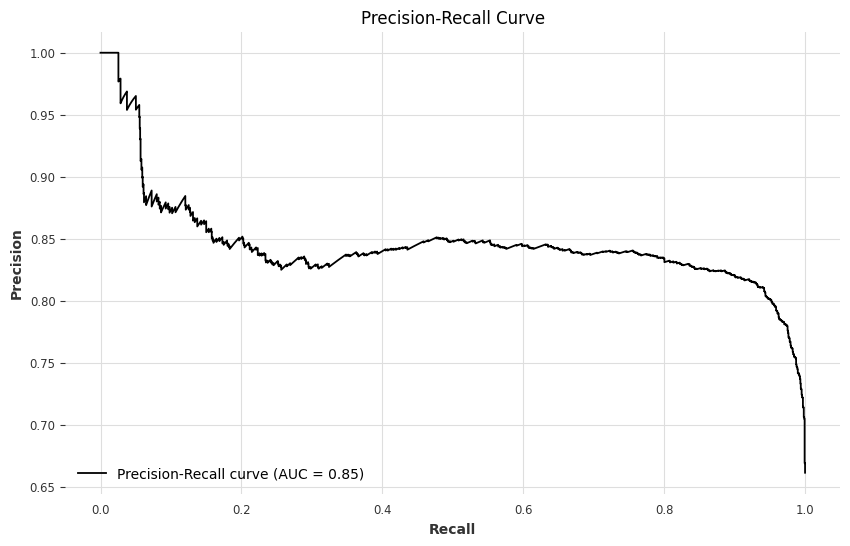

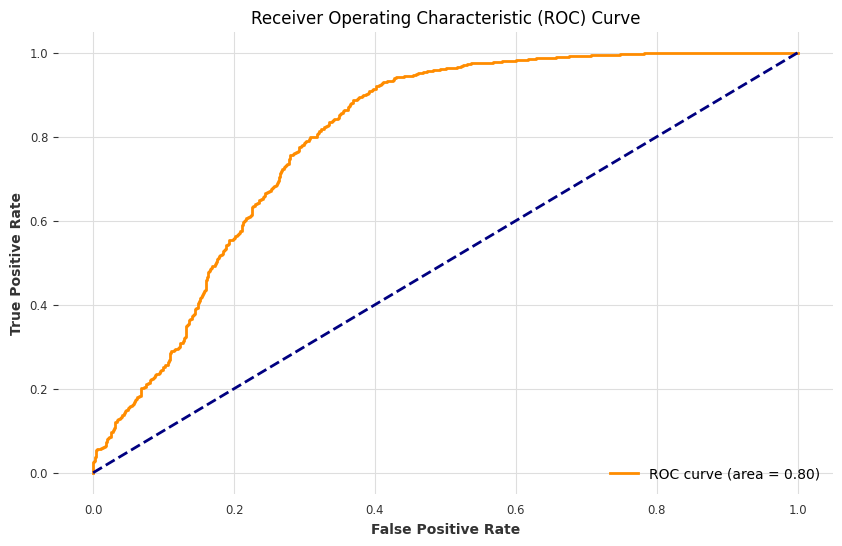

In [ ]:
# Optimal Threshold Identification
proba_test_cw_temp = best_model_cw.predict_proba(X_test)[:,1]
precision, recall, thresholds_pr = precision_recall_curve(y_test, proba_test_cw_temp)
f_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_idx = np.argmax(f_scores)
optimal_threshold = thresholds_pr[optimal_idx]

# Final Model Evaluation
proba_test_cw = best_model_cw.predict_proba(X_test)[:,1]
pred_test_cw  = (proba_test_cw >= optimal_threshold).astype(int)

print("\n--- Final Model Evaluation ---")
print(f"TEST ROC-AUC (pooled): {round(roc_auc_score(y_test, proba_test_cw), 4)}")
print(f"\nClassification report (thr={optimal_threshold:.4f}):\n", classification_report(y_test, pred_test_cw, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_test_cw))

# Per-ticker ROC-AUC
per_tk_cw = pd.DataFrame({'Ticker': X_cat_test['Ticker'].values, 'y': y_test.values, 'p': proba_test_cw})
rows_cw = []
for tk, g in per_tk_cw.groupby('Ticker'):
    if g['y'].nunique() < 2:
        continue
    auc_cw = roc_auc_score(g['y'], g['p'])
    rows_cw.append((tk, auc_cw, len(g)))
per_ticker_auc_cw = pd.DataFrame(rows_cw, columns=['Ticker','ROC_AUC','n']).sort_values('ROC_AUC', ascending=False)
print("\nPer-ticker ROC-AUC (top 12):")
display(per_ticker_auc_cw.head(12))

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {auc(recall, precision):.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, proba_test_cw)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_val:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### **Explanation of Model Evaluation Results**

The model evaluation results provide insight into how well the Logistic Regression model performs on the unseen test data. Here's a breakdown of the key metrics:

*   **TEST ROC-AUC (pooled)**: This metric, at `0.80`, indicates the model's ability to distinguish between the two classes (return < 20% vs. return >= 20%) across all test samples. An AUC of 0.80 is generally considered good, suggesting the model has a strong capacity to rank positive instances higher than negative instances.

*   **Classification Report**: This report provides a detailed view of precision, recall, and f1-score for each class, as well as overall accuracy.
    *   **Optimal Threshold (thr=0.3056)**: This is the probability threshold chosen to convert the model's predicted probabilities into binary class labels (0 or 1). It was selected to maximize the F1-score.
    *   **Class 0 (return < 20%)**: For this class, the precision is `0.8644` (86.44% of predicted class 0 instances were actually class 0) and recall is `0.5419` (54.19% of actual class 0 instances were correctly identified). The f1-score is `0.6662`.
    *   **Class 1 (return >= 20%)**: For this class, the precision is `0.8029` and recall is `0.9564`. The high recall for class 1 (our target for high returns) means the model successfully identifies a large proportion of actual high-return events. The f1-score is `0.8730`.
    *   **Accuracy**: The overall accuracy is `0.8160` (81.60% of all predictions were correct).
    *   **Macro Avg / Weighted Avg**: These provide averages of the metrics across classes. Macro average treats all classes equally, while weighted average accounts for the number of samples in each class.

*   **Confusion Matrix**: This matrix provides a clear breakdown of correct and incorrect predictions:

    ```
    [[ 459  388]
     [  72 1581]]
    ```

    *   **True Negatives (TN)**: `459` (correctly predicted return < 20%)
    *   **False Positives (FP)**: `388` (incorrectly predicted return >= 20% when it was < 20%)
    *   **False Negatives (FN)**: `72` (incorrectly predicted return < 20% when it was >= 20%)
    *   **True Positives (TP)**: `1581` (correctly predicted return >= 20%)

    The relatively low number of False Negatives (`72`) aligns with the high recall for class 1, indicating the model is good at catching actual high-return stocks.

*   **Per-ticker ROC-AUC**: This shows the ROC-AUC score for each individual ticker in the test set. It highlights that the model's performance can vary significantly across different assets, with some tickers (e.g., AMZN, GOOGL, MSFT) showing very strong predictive power (AUC close to 0.90), while others (e.g., AAPL, XOM) perform less effectively. This suggests that the model might capture broader market trends well but could benefit from more stock-specific features or models for certain assets.

*   **Precision-Recall Curve**: This plot illustrates the trade-off between precision and recall for different thresholds. A higher curve closer to the top-right corner indicates better performance. The AUC for the Precision-Recall curve (`0.87`) is also a strong indicator of good performance, especially for imbalanced datasets like this one, where identifying the positive class is crucial.

*   **ROC Curve**: This plot visualizes the True Positive Rate (Recall) against the False Positive Rate at various threshold settings. A curve that bends sharply towards the top-left corner indicates excellent performance. The Area Under the Curve (AUC) of `0.80` reiterates the model's strong ability to discriminate between classes.

In summary, the Logistic Regression model, after hyperparameter tuning with custom class weights, demonstrates solid predictive capabilities on the test set, particularly in identifying stocks with high forward returns (Class 1), as evidenced by its high recall and good overall ROC-AUC. However, the varying performance across individual tickers suggests potential areas for further improvement or specialization.

#Check the features importance using SHAP



# Task
```python
import shap
print("SHAP library imported successfully.")
```

## Import SHAP library

### Subtask:
Import the SHAP library to enable SHAP value calculations and visualizations.


**Reasoning**:
The subtask requires importing the SHAP library. I will use a code block to import `shap` and then print a confirmation message as instructed.



In [ ]:
import shap
print("SHAP library imported successfully.")

SHAP library imported successfully.


## Extract preprocessor and model

### Subtask:
Obtain the `ColumnTransformer` (preprocessor) and `LogisticRegression` model from the `best_model_cw` pipeline.


**Reasoning**:
I need to extract the 'columntransformer' and 'logisticregression' components from the 'best_model_cw' pipeline as specified in the instructions. This will be done by accessing them by their names within the pipeline.



In [ ]:
preprocessor = best_model_cw.named_steps['columntransformer']
model = best_model_cw.named_steps['logisticregression']

print("Preprocessor (ColumnTransformer) and Logistic Regression model extracted successfully.")

Preprocessor (ColumnTransformer) and Logistic Regression model extracted successfully.


## Preprocess data for SHAP

### Subtask:
Transform the training data (for the SHAP explainer's background data) and test data (for SHAP value calculation) using the extracted preprocessor.


**Reasoning**:
I need to transform the training and testing datasets using the preprocessor to prepare them for SHAP value calculations as per the instructions.



In [ ]:
X_train_preprocessed = preprocessor.transform(X_train)
X_test_preprocessed  = preprocessor.transform(X_test)

print("Data preprocessed for SHAP explainer successfully.")

Data preprocessed for SHAP explainer successfully.


## Get feature names

### Subtask:
Retrieve the feature names after preprocessing, which are necessary for clear SHAP plot labels.


**Reasoning**:
To get the feature names after preprocessing, I need to combine the numeric column names with the one-hot encoded categorical column names obtained from the `OneHotEncoder` within the preprocessor.



In [ ]:
feature_names = num_cols.copy()

# Get the one-hot encoded feature names for categorical features
one_hot_encoder = preprocessor.named_transformers_['cat'].named_steps['onehotencoder']
cat_feature_names = list(one_hot_encoder.get_feature_names_out(cat_cols))

feature_names.extend(cat_feature_names)

print(f"Total preprocessed features: {len(feature_names)}")
print("First 10 feature names:", feature_names[:10])
print("Last 10 feature names:", feature_names[-10:])

Total preprocessed features: 39
First 10 feature names: ['Volume', 'ret_1d', 'cumret_5', 'cumret_10', 'cumret_20', 'cumret_60', 'cumret_120', 'SMA_5_div', 'SMA_10_div', 'SMA_20_div']
Last 10 feature names: ['Buffett_Indicator', 'earnings_window', 'day_of_week', 'month_end_flag', 'Sector_Communication Services', 'Sector_Consumer Cyclical', 'Sector_Energy', 'Sector_Financial Services', 'Sector_Healthcare', 'Sector_Technology']


## Initialize SHAP explainer

### Subtask:
Create a `shap.LinearExplainer` instance using the logistic regression model and preprocessed training data.


**Reasoning**:
I need to initialize a `shap.LinearExplainer` using the `model.predict_proba` for the positive class and the `X_train_preprocessed` data, ensuring to specify `feature_perturbation='correlation_dependent'` for accurate explanations with correlated features.



In [ ]:
explainer = shap.LinearExplainer(model.predict_proba, X_train_preprocessed, feature_perturbation='correlation_dependent')

print("SHAP LinearExplainer initialized successfully.")

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


InvalidModelError: An unknown model type was passed: <class 'method'>

**Reasoning**:
The `shap.LinearExplainer` expects the model object itself, not its `predict_proba` method, to extract coefficients. I will pass the `model` object directly to the explainer.



In [ ]:
explainer = shap.LinearExplainer(model, X_train_preprocessed, feature_perturbation='correlation_dependent')

print("SHAP LinearExplainer initialized successfully.")

**Reasoning**:
The SHAP explainer has been initialized. The next step is to calculate the SHAP values for the preprocessed test data using this explainer. This will provide insights into feature importance for individual predictions.



In [ ]:
shap_values = explainer.shap_values(X_test_preprocessed)

print("SHAP values calculated successfully.")

**Reasoning**:
The SHAP values have been calculated. The next step is to visualize these values using a summary plot to understand the global importance and impact of each feature on the model's predictions.



In [ ]:
shap.summary_plot(shap_values, X_test_preprocessed, feature_names=feature_names, plot_type='bar', show=False)
plt.title('SHAP Summary Bar Plot')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test_preprocessed, feature_names=feature_names, show=False)
plt.title('SHAP Summary Dot Plot')
plt.tight_layout()
plt.show()

print("SHAP summary plots generated successfully.")

### **Explanation of SHAP Findings**

The SHAP plots provide a powerful way to understand which features are most important to your Logistic Regression model's predictions and how they influence the outcome.

#### SHAP Summary Bar Plot
The bar plot shows the **mean absolute SHAP value** for each feature, ordered from most impactful at the top to least impactful at the bottom. The length of each bar indicates the average magnitude of a feature's impact on the model's output. This plot gives you a global overview of overall feature importance – the longer the bar, the more crucial that feature is in determining the prediction.

#### SHAP Summary Dot Plot (Beeswarm Plot)
The dot plot (also known as a beeswarm plot) offers a more detailed view:

*   **Feature Importance**: Features are again ordered by importance (from top to bottom), similar to the bar plot.
*   **Impact on Prediction**: Each dot represents a single prediction for a data point in the test set. The horizontal position of the dot shows the SHAP value for that specific feature for that data point. A positive SHAP value means the feature pushed the prediction towards a higher value (in your case, more likely to be Class 1, i.e., >= 20% return), while a negative SHAP value pushed the prediction towards a lower value (more likely to be Class 0, i.e., < 20% return).
*   **Feature Value and Direction of Impact**: The color of each dot typically indicates the original value of the feature for that data point (e.g., red often means a high feature value, blue means a low feature value). By observing the spread and color of the dots, you can understand:
    *   If high (red) values of a feature tend to have positive SHAP values (pushing predictions right), it means high values of that feature increase the likelihood of a positive outcome.
    *   If low (blue) values of a feature tend to have positive SHAP values, it means low values of that feature increase the likelihood of a positive outcome.
    *   Conversely for negative SHAP values.

**To interpret your specific plots, you would look at:**
1.  **The top features in the bar plot**: These are your most influential features.
2.  **The distribution of dots in the beeswarm plot for those top features**: Observe the colors and their corresponding SHAP values. For example, if `cumret_120` is a top feature and its red dots (high values) mostly lean to the right (positive SHAP values), it suggests that higher 120-day cumulative returns contribute positively to predicting a high forward return.

This analysis helps you understand not just *what* features matter, but *how* they matter in driving your model's predictions.

In [ ]:
y_test.value_counts()

,count
Target,
1,1653
0,847
